# P5: YOLOv8 Training (GPU Accelerated)

This notebook handles the training of our merged 84-class dataset (80 COCO + 4 Hazards).

In [2]:
%pip install ultralytics


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:


# Install the CUDA 12.1 enabled version (standard for modern NVIDIA GPUs)
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121Note: you may need to restart the kernel to use updated packages.




[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import torch
import ultralytics
from ultralytics import YOLO

# Check if GPU is available
print(f"PyTorch Version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA is available! GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = 0 # Use the first GPU
else:
    print(" CUDA NOT found. Training will be SLOW on CPU.")
    DEVICE = 'cpu'

PyTorch Version: 2.5.1+cu121
CUDA is available! GPU: NVIDIA GeForce RTX 2050


In [3]:
import os
import yaml
from tqdm import tqdm
from pathlib import Path

# 1. Define the mappings
SCRAMBLED_NAMES = ['potted plant', 'tv', 'chair', 'person', 'microwave', 'refrigerator', 'book', 'clock', 'vase', 'dining table', 'bear', 'bed', 'stop sign', 'truck', 'car', 'teddy bear', 'skis', 'oven', 'sports ball', 'baseball glove', 'tennis racket', 'handbag', 'backpack', 'bird', 'boat', 'cell phone', 'train', 'sandwich', 'bowl', 'surfboard', 'laptop', 'mouse', 'keyboard', 'bus', 'cat', 'airplane', 'zebra', 'tie', 'traffic light', 'apple', 'baseball bat', 'knife', 'cake', 'wine glass', 'cup', 'spoon', 'banana', 'donut', 'bottle', 'sink', 'toilet', 'broccoli', 'skateboard', 'fork', 'carrot', 'couch', 'remote', 'scissors', 'bicycle', 'sheep', 'bench', 'orange', 'elephant', 'frisbee', 'umbrella', 'horse', 'dog', 'motorcycle', 'kite', 'pizza', 'fire hydrant', 'suitcase', 'hot dog', 'cow', 'giraffe', 'snowboard', 'parking meter', 'toothbrush', 'toaster', 'hair drier', 'Pothole', 'Road Crack', 'Open Manhole', 'Stairs']

STANDARD_COCO = ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']

HAZARDS = ['Pothole', 'Road Crack', 'Open Manhole', 'Stairs']
FINAL_ORDER = STANDARD_COCO + HAZARDS

# Create a lookup: {old_id: new_id}
id_map = {}
for old_idx, name in enumerate(SCRAMBLED_NAMES):
    new_idx = FINAL_ORDER.index(name)
    id_map[old_idx] = new_idx

# 2. Process all label files in the FINAL dataset
label_dirs = [
    r'c:\SafeStride\Dataset preprocessing\final_dataset\train\labels',
    r'c:\SafeStride\Dataset preprocessing\final_dataset\val\labels',
    r'c:\SafeStride\Dataset preprocessing\final_dataset\test\labels'
]

print("Remapping labels in final_dataset to standard COCO order...")
for ldir in label_dirs:
    path = Path(ldir)
    if not path.exists(): 
        print(f"Skipping {ldir} (not found)")
        continue
    
    for lbl_file in tqdm(list(path.glob("*.txt")), desc=f"Processing {path.parent.name}"):
        with open(lbl_file, 'r') as f:
            lines = f.readlines()
        
        new_lines = []
        for line in lines:
            parts = line.split()
            if not parts: continue
            old_cls = int(parts[0])
            if old_cls in id_map:
                new_cls = id_map[old_cls]
                new_lines.append(f"{new_cls} {' '.join(parts[1:])}\n")
            else:
                new_lines.append(line) # Keep as is if not in map
            
        with open(lbl_file, 'w') as f:
            f.writelines(new_lines)

# 3. Rewrite the final_training_config.yaml
yaml_path = r'c:\SafeStride\Dataset preprocessing\final_training_config.yaml'
config = {
    'train': r'c:\SafeStride\Dataset preprocessing\final_dataset\train\images',
    'val': r'c:\SafeStride\Dataset preprocessing\final_dataset\val\images',
    'test': r'c:\SafeStride\Dataset preprocessing\final_dataset\test\images',
    'nc': 84,
    'names': FINAL_ORDER
}

with open(yaml_path, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print("\nSuccess! Labels remapped and YAML updated to standard COCO + 4 Hazards.")


Remapping labels in final_dataset to standard COCO order...


Processing test: 100%|██████████| 1793/1793 [00:14<00:00, 122.31it/s]


Success! Labels remapped and YAML updated to standard COCO + 4 Hazards.


In [ ]:
import torch
from ultralytics import YOLO

DATASET_YAML = r'C:\SafeStride\Dataset preprocessing\final_training_config.yaml'
BASE_WEIGHTS = 'yolov8m.pt'
PROJECT_DIR  = 'SafeStride_Runs'
EPOCHS       = 50
BATCH_SIZE   = 8     # Safe for RTX 2050 (4GB VRAM)
IMAGE_SIZE   = 640
WORKERS      = 2     # Must be low on Windows

print(f"PyTorch: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} ")
    DEVICE = 0
else:
    print("No GPU found, using CPU")
    DEVICE = 'cpu'

model = YOLO(BASE_WEIGHTS)

results = model.train(
    data          = DATASET_YAML,
    epochs        = EPOCHS,
    imgsz         = IMAGE_SIZE,
    batch         = BATCH_SIZE,
    workers       = WORKERS,
    device        = DEVICE,
    project       = PROJECT_DIR,
    name          = 'safestride_84cls',
    cache         = False,
    amp           = True,
    patience      = 20,
    save          = True,
    save_period   = 10,
    verbose       = True,
)   

print(f"\n Training complete!")
print(f"Best model saved at: {PROJECT_DIR}/safestride_84cls/weights/best.pt")


PyTorch: 2.5.1+cu121
GPU: NVIDIA GeForce RTX 2050 
New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=yolov8m.pt, data=C:\SafeStride\Dataset preprocessing\final_training_config.yaml, epochs=50, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=2, project=SafeStride_Runs, name=safestride_84cls, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, v

train: Scanning C:\SafeStride\Dataset preprocessing\final_dataset\train\labels.cache... 8363 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8363/8363 [00:00<?, ?it/s]
val: Scanning C:\SafeStride\Dataset preprocessing\final_dataset\val\labels.cache... 1792 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1792/1792 [00:00<?, ?it/s]


Plotting labels to SafeStride_Runs\safestride_84cls\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000114, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to SafeStride_Runs\safestride_84cls
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50      7.58G      1.158      2.413      1.306         12        640: 100%|██████████| 1046/1046 [1:17:27<00:00,  4.44s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [05:30<00:00,  2.95s/it]


                   all       1792       7678      0.621      0.478      0.513      0.365

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1792       7678      0.536      0.473       0.47       0.33

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       6/50      7.44G      1.084       1.34      1.249         26        640: 100%|██████████| 1046/1046 [1:11:20<00:00,  4.09s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [06:19<00:00,  3.39s/it]


                   all       1792       7678      0.568      0.471      0.474      0.334

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       7/50      7.46G      1.069      1.294      1.239         12        640: 100%|██████████| 1046/1046 [1:15:29<00:00,  4.33s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  61%|██████    | 68/112 [03:14<02:05,  2.85s/it]


KeyboardInterrupt: 

In [2]:
from ultralytics import YOLO



In [2]:

model = YOLO(r'C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt')

model.train(resume=True)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

engine\trainer: task=detect, mode=train, model=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, data=C:\SafeStride\Dataset preprocessing\final_training_config.yaml, epochs=50, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=2, project=SafeStride_Runs, name=safestride_84cls, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, s

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


...

                   all       1792       7678      0.629      0.458        0.5      0.354

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      15/50      3.85G     0.9866      1.035      1.182         31        640: 100%|██████████| 1046/1046 [18:16<00:00,  1.05s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [01:50<00:00,  1.02it/s]


                   all       1792       7678      0.567      0.479        0.5      0.354

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      16/50      3.81G     0.9867      1.011      1.167         34        640:  18%|█▊        | 186/1046 [02:45<12:44,  1.12it/s]


KeyboardInterrupt: 

In [3]:

model = YOLO(r'C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt')

model.train(resume=True)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, data=C:\SafeStride\Dataset preprocessing\final_training_config.yaml, epochs=50, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=2, project=SafeStride_Runs, name=safestride_84cls, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False,

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


...

      36/50      3.81G     0.8331     0.7047      1.077         13        640: 100%|██████████| 1046/1046 [1:56:29<00:00,  6.68s/it]   
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [02:11<00:00,  1.18s/it]

                   all       1792       7678        0.6       0.52      0.535      0.386



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      37/50      3.82G     0.8652     0.7056      1.079         60        640:   1%|          | 8/1046 [00:07<16:39,  1.04it/s]


KeyboardInterrupt: 

In [11]:

model = YOLO(r'C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt')

model.train(resume=True)


New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, data=C:\SafeStride\Dataset preprocessing\final_training_config.yaml, epochs=50, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=2, project=SafeStride_Runs, name=safestride_84cls, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=

train: Scanning C:\SafeStride\Dataset preprocessing\final_dataset\train\labels.cache... 8363 images, 0 backgrounds, 0 corrupt: 100%|██████████| 8363/8363 [00:00<?, ?it/s]
val: Scanning C:\SafeStride\Dataset preprocessing\final_dataset\val\labels.cache... 1792 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1792/1792 [00:00<?, ?it/s]


Plotting labels to SafeStride_Runs\safestride_84cls\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000114, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Resuming training C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt from epoch 37 to 50 total epochs
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to SafeStride_Runs\safestride_84cls
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      37/50      4.07G     0.7714     0.6212      1.044         12        640: 100%|██████████| 1046/1046 [1:08:06<00:00,  3.91s/it]   
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [03:04<00:00,  1.64s/it]

                   all       1792       7678      0.598      0.518      0.531       0.38


...

      38/50      3.82G     0.7663     0.6029      1.038         20        640: 100%|██████████| 1046/1046 [1:38:10<00:00,  5.63s/it]   
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [02:00<00:00,  1.07s/it]

                   all       1792       7678      0.617      0.507      0.531      0.382



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      39/50      3.82G     0.7505      0.581      1.037         96        640:  16%|█▋        | 172/1046 [2:19:26<11:48:33, 48.64s/it]   


KeyboardInterrupt: 

In [1]:
from ultralytics import YOLO

In [2]:

model = YOLO(r'C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt')

model.train(resume=True)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: task=detect, mode=train, model=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, data=C:\SafeStride\Dataset preprocessing\final_training_config.yaml, epochs=50, time=None, patience=20, batch=8, imgsz=640, save=True, save_period=10, cache=False, device=0, workers=2, project=SafeStride_Runs, name=safestride_84cls, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\last.pt, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False,

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


...

                   all       1792       7678      0.655      0.484      0.533      0.382



12 epochs completed in 9.283 hours.
Optimizer stripped from SafeStride_Runs\safestride_84cls\weights\last.pt, 52.1MB
Optimizer stripped from SafeStride_Runs\safestride_84cls\weights\best.pt, 52.1MB

Validating SafeStride_Runs\safestride_84cls\weights\best.pt...
Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 218 layers, 25888396 parameters, 0 gradients, 79.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 112/112 [00:50<00:00,  2.22it/s]


                   all       1792       7678      0.598      0.518      0.535      0.385
                person       1792       1605      0.694      0.725      0.742      0.507
               bicycle       1792         34      0.566      0.412      0.453      0.223
                   car       1792        313      0.648      0.546      0.529      0.342
            motorcycle       1792         55       0.77      0.618      0.768      0.443
              airplane       1792         26      0.775      0.662      0.751      0.551
                   bus       1792         43      0.709      0.581       0.63      0.501
                 train       1792         30      0.961      0.822      0.888      0.621
                 truck       1792         70      0.478        0.5      0.478      0.274
                  boat       1792         56      0.432      0.394      0.387      0.184
         traffic light       1792         88      0.487      0.511      0.459      0.245
          fire hydran

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77,
       78, 79, 80, 81, 82, 83])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000282154047F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023


image 1/1 C:\SafeStride\Dataset preprocessing\test2.jpg: 448x640 19 Potholes, 45.0ms
Speed: 2.0ms preprocess, 45.0ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)
Results saved to runs\detect\predict14


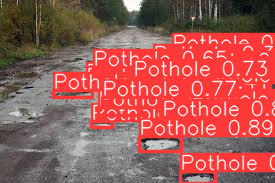

Detected classes: ['Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole', 'Pothole']


In [ ]:
from ultralytics import YOLO
import cv2
from PIL import Image

# 1. Added 'r' before the string to fix the backslash issue
model = YOLO(r'C:\SafeStride\Dataset preprocessing\SafeStride_Runs\safestride_84cls\weights\best.pt')

# 2. Added 'r' here too for safety
image_path = r'C:\SafeStride\Dataset preprocessing\coco_reminder_set\images\000000006954.jpg' 

# 3. Run inference
results = model.predict(source=image_path, conf=0.25, save=True)

# 4. Show the results
for r in results:
    im_array = r.plot()  
    im = Image.fromarray(im_array[..., ::-1])  
    display(im)
    print("Detected classes:", [model.names[int(cls)] for cls in r.boxes.cls])


In [1]:
from ultralytics import YOLO


weights_path = 'SafeStride_Runs/safestride_84cls/weights/best.pt'
model = YOLO(weights_path)

print("Checking accuracy of loaded weights...")
metrics = model.val(
    data='final_training_config.yaml', 
    split='val',
    workers=0,  
    batch=4     
)

print(f"Starting mAP50 is: {metrics.box.map50:.4f}")


Checking accuracy of loaded weights...
Ultralytics YOLOv8.2.18  Python-3.10.11 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)


c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\ultralytics\nn\tasks.py:732: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, ma

Model summary (fused): 218 layers, 25888396 parameters, 0 gradients, 79.0 GFLOPs


val: Scanning C:\SafeStride\Dataset preprocessing\final_dataset\val\labels.cache... 1792 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1792/1792 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 448/448 [01:18<00:00,  5.68it/s]


                   all       1792       7678      0.601      0.522      0.536      0.386
                person       1792       1605      0.697      0.725      0.743      0.508
               bicycle       1792         34      0.596      0.434      0.456      0.227
                   car       1792        313      0.645      0.546      0.525       0.34
            motorcycle       1792         55      0.769      0.618      0.767      0.442
              airplane       1792         26      0.779      0.692      0.765      0.564
                   bus       1792         43      0.684      0.581      0.628        0.5
                 train       1792         30      0.961      0.822      0.886       0.62
                 truck       1792         70       0.47      0.471      0.458      0.266
                  boat       1792         56      0.459      0.411      0.388      0.186
         traffic light       1792         88      0.493      0.511      0.462      0.244
          fire hydran